# Assignment 1

## A bit of info before you start.


> ***First and foremost, dont use AI to code. Use it to understand and then write code yourself. Use AI to verify if the code you wrote it correct, that will help you learn far far more.***
[link text](https:// [link text](https://))
> ***Implement Stuff from sratch. Use cv2 functions only when numpy implementation can be extremely tedious.***



You will need to use your own image for this assignment, which you need to import into here.
If you cant fetch your image from any APIs that dont need credentials, then :
To preserve an image in Google Colab without a continuous runtime or using Google Drive, you can use base64 string encoding of images ( its really simple )

First, begin by normally uploading the image into the contents folders as you normally do in colab or fetch it using Drive or any API.

To get the base64 string :
```
import base64
with open("your_image.jpg", "rb") as img_file:
    print(base64.b64encode(img_file.read()).decode())
```

Note that the base64 string is a very long string, click on the three dot icon to the left of the current code cell and click on <code> Copy Cell Output </code> to easily copy it to your clipboard.

Then, to embed the string into your Jupyter Notebook :
```
from PIL import Image
import io
import base64
import matplotlib.pyplot as plt
import numpy as np

# PASTE BASE64 STRING HERE
base64_image = "iVBORw0K..."  # long base64 string

img_data = base64.b64decode(base64_image)
img = Image.open(io.BytesIO(img_data))

plt.imshow(img)
plt.axis("off")
```
The string is really long so, use a multiline string in python ( syntax : """ """ )

Otherwise, you can also choose to use any API ( try researching on https://picsum.photos/ )

## Part A

### Load your image

1. Display it in RGB

2. Convert to grayscale ( use NumPy to calculate aggregates using the weighted sum formula )

3. Use the cvtColor function to do the same and compare results

3. Print the array shapes of both the RGB and grayscale images

4. Print a few pixel values of both

( Do you notice the difference that number of channels created on the array shape ?? )

In [94]:
# Your PART A codes follow here. You can create more cells under this. Write clean and commented code.
import base64
with open("790-1000x500.jpg", "rb") as img_file:
    print(base64.b64encode(img_file.read()).decode())


...


(np.float64(-0.5), np.float64(999.5), np.float64(499.5), np.float64(-0.5))

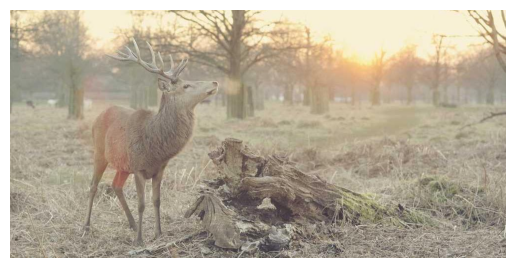

In [95]:
from PIL import Image
import io
import base64
import matplotlib.pyplot as plt
import numpy as np
import cv2
# PASTE BASE64 STRING HERE
base64_image = """...
"""  # long base64 string

img_data = base64.b64decode(base64_image)
img = Image.open(io.BytesIO(img_data))

plt.imshow(img)
plt.axis("off")

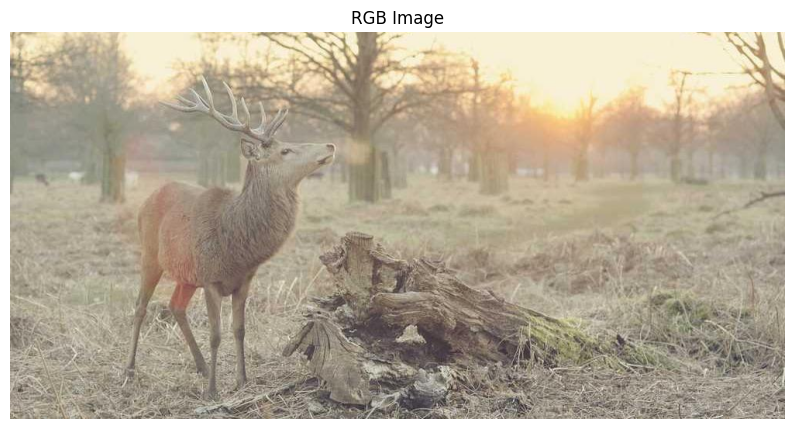

In [ ]:
#1 RGB display
img = cv2.imread('790-1000x500.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.title('RGB Image')
plt.axis('off')
plt.show()
#Grayscale conversion using numpy



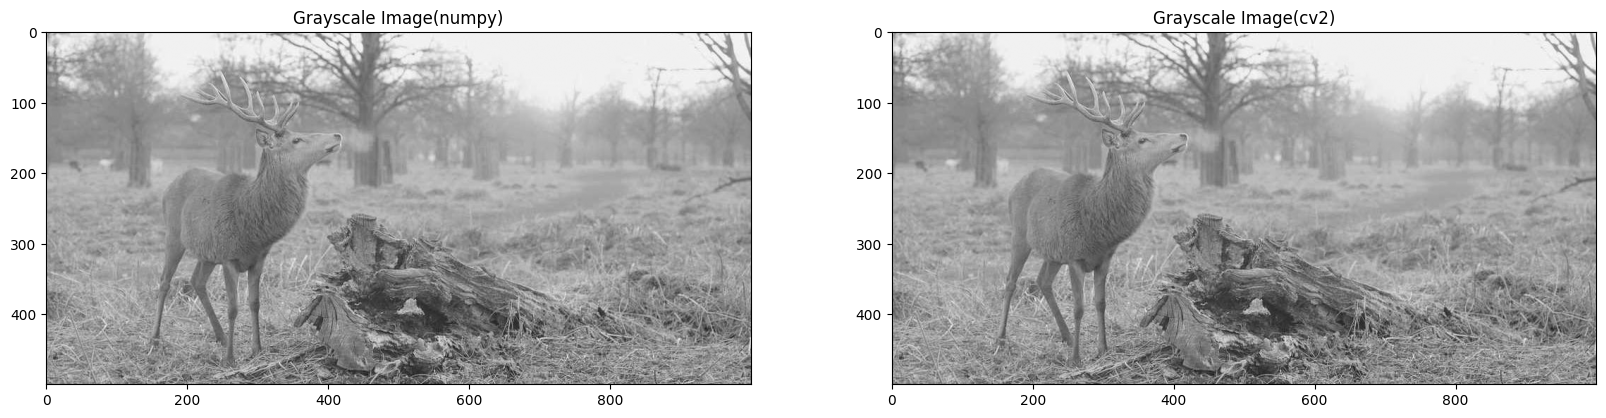

Shape of RGB image:  (500, 1000, 3)
Shape of Grayscale image:  (500, 1000)
RGB pixel values:  [[[218 202]
  [216 200]
  [210 194]
  [196 180]
  [180 164]]

 [[223 207]
  [221 205]
  [210 194]
  [190 174]
  [174 158]]

 [[219 203]
  [218 202]
  [202 186]
  [176 160]
  [163 147]]

 [[209 193]
  [209 193]
  [192 176]
  [167 151]
  [162 146]]

 [[202 186]
  [201 185]
  [187 171]
  [170 154]
  [174 158]]]
Grayscale pixel values: [[203 201 195 181 165]
 [208 206 195 175 159]
 [204 203 187 161 148]
 [194 194 177 152 147]
 [187 186 172 155 159]]


In [96]:
# 2,3 Comaprison of numpy and cv2 of grayscale conversion
plt.figure(figsize=(20, 20))
#Grayscale display using numpy
r,g,b = cv2.split(img_rgb)
gray = 0.2989 * r + 0.5870 * g + 0.11*b
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image(numpy)')
#using cv2
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale Image(cv2)')
plt.show()
# Results are similar

#4 Shapes of RGB and Grayscale
print("Shape of RGB image: ", img_rgb.shape)
print("Shape of Grayscale image: ", img_gray.shape)

#5 Displaying few pixel values
print("RGB pixel values: ", img_rgb[0:5, 0:5,0:2])
print("Grayscale pixel values:",img_gray[0:5,0:5])


## Part B
### B1. Compute the FFT of the grayscale image ( use NumPy )
Steps:
1. <code>np.fft.fft2</code>
2. <code>np.fft.fftshift</code>
3. Store as <code>fshift</code>

### B2. Compute magnitude, phase and display Magnitude Spectrum

In [97]:
# Your PART B1 codes follow here. You can create more cells under this. Write clean and commented code.
#FFT
gray_float=gray.astype(np.float32)
f = np.fft.fft2(gray_float)
fshift = np.fft.fftshift(f)
#Magnitude

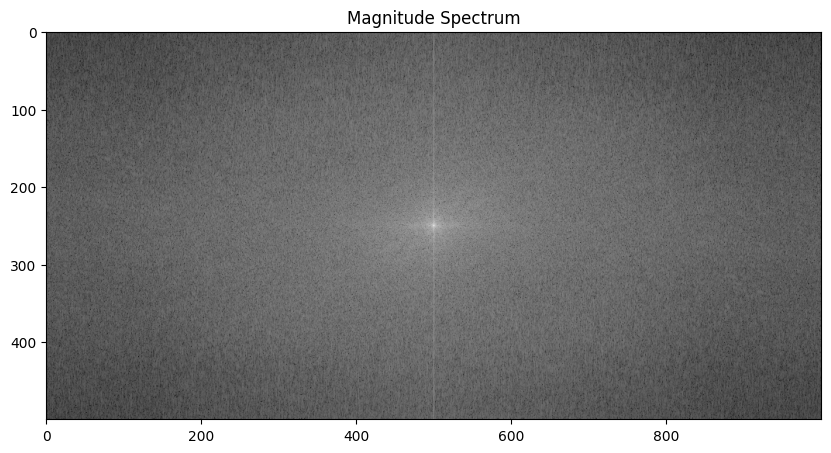

In [98]:
#B2 Magnitude and Phase
magnitude = 20*np.log(np.abs(fshift)+1)
phase = np.angle(fshift)
plt.figure(figsize=(10, 10))
plt.title('Magnitude Spectrum')
plt.imshow(magnitude, cmap='gray')

## Part C
### C1. Create 3 LPF masks

Radii of filter: 10, 30, 80 (or image-size dependent, mention if you change)

For each:

1. Create a mask

2. Apply to <code>fshift</code>

3. Reconstruct using <code>ifftshift + ifft2</code>

4. Show blur levels increasing as radius decreases ( think why and write reason in code comment )

### C2. Create HPF mask

1. Apply

2. Reconstruct

### C3. Create a square LPF mask
Keep side of square as 50. The square will be at the center of the filter.
Apply, Recontruct and show the output.

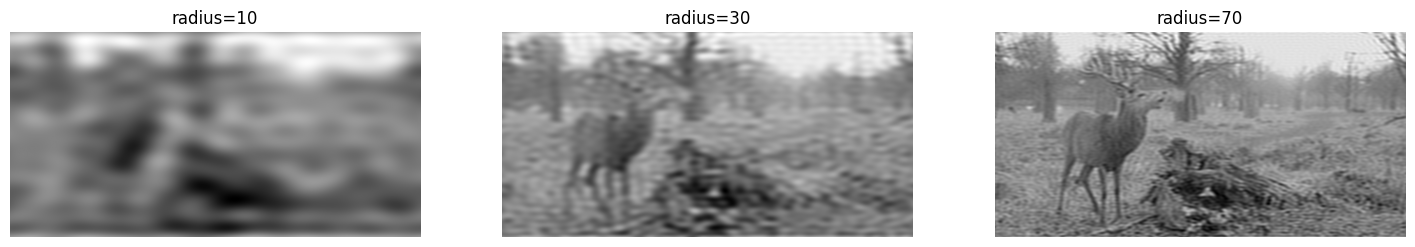

In [99]:
# C1 Low Pass Filters
plt.figure(figsize=(18, 6))
rows, cols = gray.shape
crows, ccols = rows // 2, cols // 2

radii = [10, 30, 70]

for i, radius in enumerate(radii, start=1):

    # Create mask
    mask_lpf = np.zeros((rows, cols), np.uint8)
    cv2.circle(mask_lpf, (ccols, crows), radius, 1, -1)

    # Apply LPF
    f_lpf = fshift * mask_lpf

    # Inverse FFT
    f_ishift_lpf = np.fft.ifftshift(f_lpf)
    img_back_lpf = np.fft.ifft2(f_ishift_lpf)
    img_back_lpf = np.abs(img_back_lpf)

    # Plot
    plt.subplot(1, 3, i)
    plt.imshow(img_back_lpf, cmap='gray')
    plt.title(f'radius={radius}')
    plt.axis('off')

plt.show()


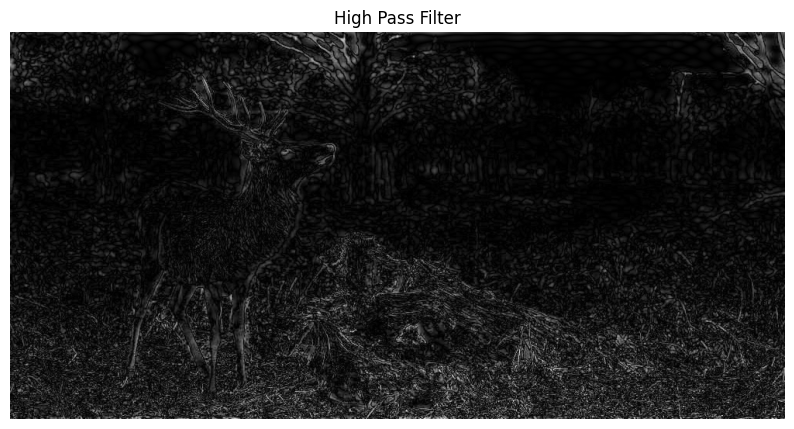

In [100]:
#C2 High Pass filter
rows,cols=gray.shape
crows,ccols=rows//2,cols//2
radius=30
mask_lpf=np.zeros((rows,cols),np.uint8)
mask_hpf=1-mask_lpf
cv2.circle(mask_hpf,(ccols,crows),radius,0,-1)
f_hpf=fshift*mask_hpf
# Inverse FFT for HPF
f_ishift_hpf=np.fft.ifftshift(f_hpf)
img_back_hpf=np.fft.ifft2(f_ishift_hpf)
img_back_hpf=np.abs(img_back_hpf)
plt.figure(figsize=(10, 10))
plt.title('High Pass Filter')
plt.imshow(img_back_hpf, cmap='gray')
plt.axis('off')
plt.show()

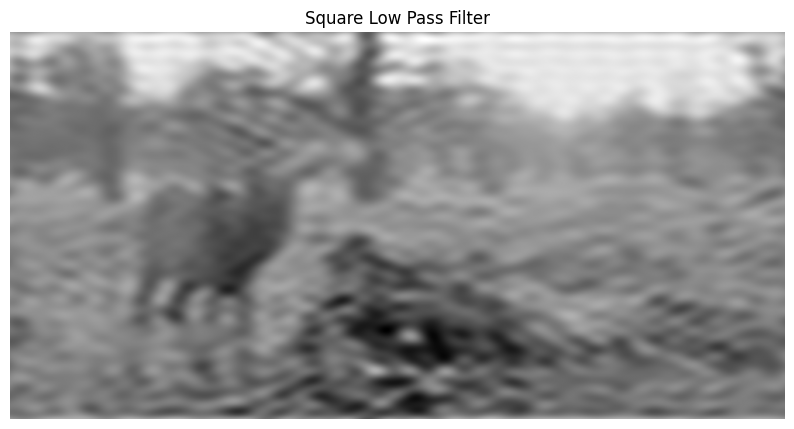

In [101]:
# Square LPF
rows,cols=gray.shape
crows,ccols=rows//2,cols//2
mask_lpf=np.zeros((rows,cols),np.uint8)
mask_lpf[crows-25:crows+25,ccols-25:ccols+25]=1
f_lpf=fshift*mask_lpf
# Inverse FFT
f_ishift_lpf=np.fft.ifftshift(f_lpf)
img_back_lpf=np.fft.ifft2(f_ishift_lpf)
img_back_lpf=np.abs(img_back_lpf)
plt.figure(figsize=(10, 10))
plt.title('Square Low Pass Filter')
plt.imshow(img_back_lpf,cmap='gray')
plt.axis('off')
plt.show()
# Square LPF : different slices of horizontal and vertical frequencies

## Part D

###D1. Phase-only reconstruction

Use: <code>phase_only = fshift / np.abs(fshift)</code>

1. Reconstruct and display.
2. Also in code comments, mention the differnce between this code line and the one in the lecture : <code>np.angle(f_shift)</code>
3. Try recontruction from <code>np.angle(f_shift)</code> once and explain your output in code comments.



###D2. Magnitude-only reconstruction

Use: <code>mag_only = np.abs(fshift)</code>

1. Reconstruct and display.
2. Take a guess for the role of logarithm in Magnitude Spectrum. Why does this look different than what Magnitude Spectrum looked like ? Mention in code comments again.

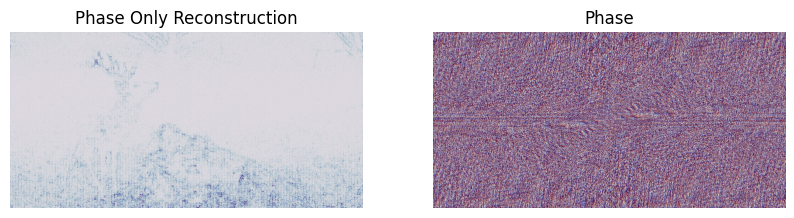

In [103]:
# D1
plt.figure(figsize=(10, 10))
phase_only = fshift / np.abs(fshift)
f_ishift_phase = np.fft.ifftshift(phase_only)
img_back_phase = np.fft.ifft2(f_ishift_phase)
img_back_phase = np.abs(img_back_phase)
plt.subplot(1,2,1)
plt.title('Phase Only Reconstruction')
plt.imshow(img_back_phase,cmap='twilight')
plt.axis('off')

#  Difference in the approaches
# 1) np.angle uses to directly find the arguument( real-valued as it corresponds to value 'theta')
# 2) fshift/abs(fshift) gives us a point on unit circle with argument theta( complex-valued as it corresponds to e^i*theta)

 # Using np.angle(f_shift)
phase=np.angle(fshift)
plt.subplot(1,2,2)
plt.title('Phase')
plt.imshow(phase,cmap='twilight')
plt.axis('off')
plt.show()


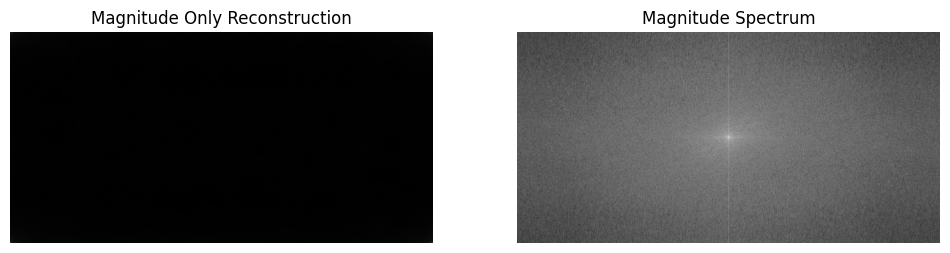

In [104]:
# Magnitude Only Reconstruction
mag_only = np.abs(fshift)
f_ishift_mag = np.fft.ifftshift(mag_only)
img_back_mag = np.fft.ifft2(f_ishift_mag)
img_back_mag = np.abs(img_back_mag)
magnitude_spectrum=20*np.log(np.abs(fshift)+1)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Magnitude Only Reconstruction')
plt.imshow(img_back_mag,cmap='gray')
plt.axis('off')

# Magnitude Spectrum: Contains wide range of frequencies for the image(it is  not an attempt to construct an image).
# To rescale the frequency bands aroud the center,log function has been invoked to accomodate
# high frequency bands as well along with the low-frequency bands
# Magnitude Reconstruction: We have tried to construct an image only using the image (no phase component)

plt.subplot(1,2,2)
plt.title('Magnitude Spectrum')
plt.imshow(magnitude_spectrum,cmap='gray')
plt.axis('off')
plt.show()

## Bonus - Part E

Load another image as you did before. Then swap magnitude and phase between them. In other words, for both images, find the magnitudes and phases. Combine magnitude of image 1 with phase of image 2. Also combine magnitude of 2 with phase of 1. Then reconstruct and display the resultant images.

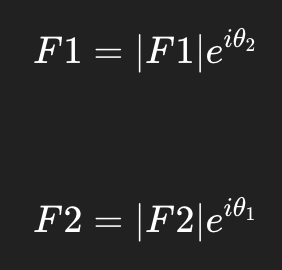

Do you notice how phase describes structure and magnitude describes texture of image ? Mention at last in code comments.


In [105]:
# E1- Extracting 2nd image
with open("515-1250x625.jpg", "rb") as img_file:
    print(base64.b64encode(img_file.read()).decode())


...


(np.float64(-0.5), np.float64(1249.5), np.float64(624.5), np.float64(-0.5))

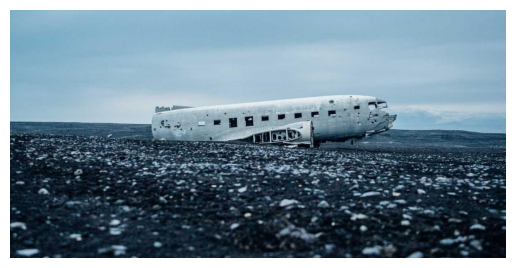

In [107]:
# Displaying 2nd image
base64_image_2 = """...
"""  # long base64 string

img_data_2 = base64.b64decode(base64_image_2)
img_2 = Image.open(io.BytesIO(img_data_2))
plt.imshow(img_2)
plt.axis("off")


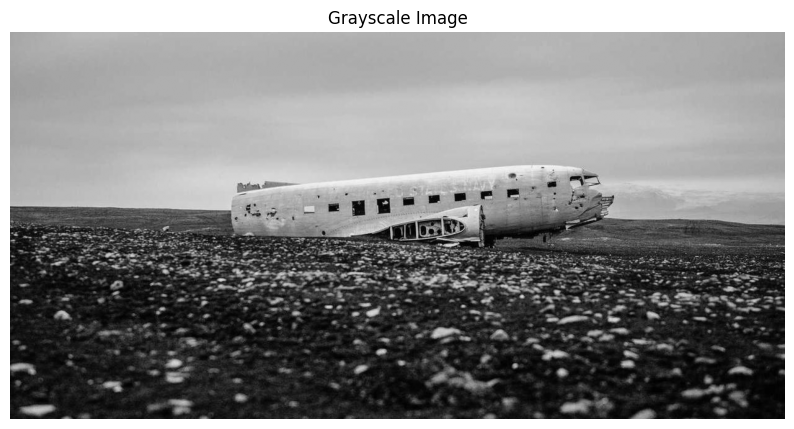

In [108]:
# Obtaining grayscale image for this image
plt.figure(figsize=(10,10))
img_2=cv2.imread('515-1250x625.jpg')
gray_2=cv2.cvtColor(img_2,cv2.COLOR_BGR2GRAY)
plt.imshow(gray_2,cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

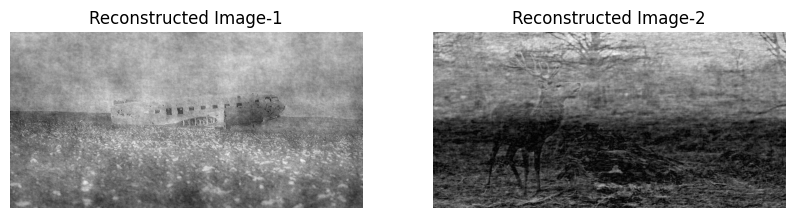

In [109]:
# F1=|F1| e^i*theta_2
# F2=|F2| e^i*theta_1
#Image-1
gray_float=gray.astype(np.float32)
f = np.fft.fft2(gray_float)
fshift=np.fft.fftshift(f)
f_mag=np.abs(fshift)
f_phase=fshift/f_mag

# Image-2
# Resize the image into 1000x1000
gray_2=cv2.resize(gray_2,(gray.shape[1],gray.shape[0]))
gray_2_float=gray_2.astype(np.float32)
f_2=np.fft.fft2(gray_2_float)
fshift_2=np.fft.fftshift(f_2)
f_2_mag=np.abs(fshift_2)
f_2_phase=fshift_2/f_2_mag

#Swapping the phases
fshift=f_mag*f_2_phase
fshift_2=f_2_mag*f_phase

#F1 Reconstruction
f_ishift=np.fft.ifftshift(fshift)
img_back=np.fft.ifft2(f_ishift)
img_back=np.abs(img_back)

#F2 reconstruction
f_2_ishift=np.fft.ifftshift(fshift_2)
img_back_2=np.fft.ifft2(f_2_ishift)
img_back_2=np.abs(img_back_2)

# Display F1
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(img_back,cmap='gray')
plt.title('Reconstructed Image-1')
plt.axis('off')

# Display F2
plt.subplot(1,2,2)
plt.imshow(img_back_2,cmap='gray')
plt.title('Reconstructed Image-2')
plt.axis('off')
plt.show()

# We notice that F1 acquires the image structure of F2 while retaining its texture and vice-versa, as we swapped their phases. Hence, phase of an image  preserves its structure and
# magnitude preserves texture